In [1]:
# ============================================================
# CELL 1 — Imports & Setup
# Load this cell first in every session
# ============================================================

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.size":        11,
})

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ============================================================
# CELL 2 — HTML Extraction Function
#
# Extracts cluster-level obs/exp data from SaTScan HTML output.
# Required for Gini computation per Han et al. (2016) and
# Wang et al. (2025).
#
# Han et al. (2016): "Using Gini coefficient to determining
# optimal cluster reporting sizes for spatial scan statistics"
# Int J Health Geogr, 15:27
# https://doi.org/10.1186/s12942-016-0056-6
# ============================================================

def extract_clusters_from_html(filepath):
    """
    Parse a SaTScan HTML cluster map output and return a list of
    cluster dicts containing the fields needed for Gini computation:
    observed_cases, expected_cases, obs_exp_ratio, llr, radius_km.
    """
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()

    meta_pattern = re.compile(
        r'\{ id: (\d+), slider_value : ([\d.]+), highrate : (\w+), '
        r'lat : ([\d.\-]+), lng : ([\d.\-]+), radius : ([\d.]+), '
        r'hierarchical : (\w+), gini : (\w+)'
    )
    meta_rows = meta_pattern.findall(content)
    tips = re.findall(r"tip : '(.*?)', edges", content, re.DOTALL)

    def decode(s):
        return html.unescape(
            s.replace('&#32;', ' ').replace('&#47;', '/')
             .replace('&#46;', '.').replace('&#45;', '-')
        )

    clusters = []
    for i, meta in enumerate(meta_rows):
        cid, slider, highrate, lat, lng, radius, hierarchical, gini_flag = meta
        row = {
            'cluster_id': int(cid),
            'radius_km':  float(radius) / 1000,
            'is_gini':    gini_flag == 'true',
        }
        if i < len(tips):
            decoded = decode(tips[i])
            obs = re.search(r'Number of cases.*?(\d+)', decoded)
            exp = re.search(r'Expected cases.*?([\d.]+)', decoded)
            rat = re.search(r'Observed / expected.*?([\d.]+)', decoded)
            llr = re.search(r'Test statistic.*?([\d.]+)', decoded)
            pv  = re.search(r'P-value.*?([\d.]+)', decoded)
            tf  = re.search(r'Time frame.*?(\d{4}/\d+/\d+)\s*to\s*(\d{4}/\d+/\d+)', decoded)
            row['observed_cases'] = int(obs.group(1))   if obs else None
            row['expected_cases'] = float(exp.group(1)) if exp else None
            row['obs_exp_ratio']  = float(rat.group(1)) if rat else None
            row['llr']            = float(llr.group(1)) if llr else None
            row['p_value']        = float(pv.group(1))  if pv  else None
            row['start_date']     = tf.group(1)          if tf  else None
            row['end_date']       = tf.group(2)          if tf  else None

        clusters.append(row)

    return pd.DataFrame(clusters)


print("extract_clusters_from_html() defined.")

extract_clusters_from_html() defined.


In [3]:
# ============================================================
# CELL 3 — Gini Coefficient Function
#
# Implements the Gini coefficient formula exactly as defined in:
#
#   Han J, Zhu L, Kulldorff M, et al. (2016)
#   "Using Gini coefficient to determining optimal cluster
#   reporting sizes for spatial scan statistics"
#   Int J Health Geogr, 15:27
#   https://doi.org/10.1186/s12942-016-0056-6
#
# Formula (Eq. 5 in paper):
#   G = Σ (y_k * x_{k-1} − y_{k-1} * x_k)  for k = 1 to K+1
#
# Where:
#   x_k = cumulative proportion of OBSERVED cases (Lorenz x-axis)
#   y_k = cumulative proportion of EXPECTED cases (Lorenz y-axis)
#   Clusters sorted in DESCENDING order of relative risk (obs/exp)
#   (x_0, y_0) = (0, 0);  (x_{K+1}, y_{K+1}) = (1, 1)
#
# Interpretation: higher G = more unequal distribution of cases
# across clusters = more concentrated, better-defined signals.
# "When comparing several competing collections of non-overlapping
# clusters, the one with the highest Gini coefficient value should
# be chosen as the cluster collection to report." (Han et al. 2016)
# ============================================================

def compute_gini(df):
    """
    Compute the Han et al. (2016) Gini coefficient for a cluster set.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'observed_cases' and 'expected_cases' columns.

    Returns
    -------
    float : Gini coefficient (0–1, higher = more concentrated signal)
    """
    valid = df[['observed_cases', 'expected_cases']].dropna()
    valid = valid[(valid['observed_cases'] > 0) & (valid['expected_cases'] > 0)]

    if len(valid) == 0:
        return np.nan

    obs = valid['observed_cases'].values.astype(float)
    exp = valid['expected_cases'].values.astype(float)

    C = obs.sum()   # total observed cases across all clusters
    N = exp.sum()   # total expected cases across all clusters

    # Sort clusters by relative risk descending (highest RR first)
    rr = obs / exp
    sort_idx = np.argsort(rr)[::-1]
    obs = obs[sort_idx]
    exp = exp[sort_idx]

    # Build Lorenz curve coordinates
    # x = cumulative proportion of observed cases
    # y = cumulative proportion of expected cases
    x = np.concatenate([[0], np.cumsum(obs) / C, [1]])
    y = np.concatenate([[0], np.cumsum(exp) / N, [1]])

    # Gini = Σ (y_k * x_{k-1} − y_{k-1} * x_k)
    G = float(np.sum(y[1:] * x[:-1] - y[:-1] * x[1:]))

    return G


print("compute_gini() defined.")

compute_gini() defined.


In [6]:
# ============================================================
# CELL 4 — Load All Runs
#
# Change file paths to match your actual HTML filenames.
# All four HTML files must be in the same folder as this
# notebook, or provide full paths.
#
# Each run varies ONLY the MaxSpatialSizeInPopulationAtRisk
# (MSWS), consistent with Wang et al. (2025) who tested
# "MSWS values of 5, 10, 15, 20, 25, 30, 40, and 50% for
# each year" and calculated Gini for each.
# All runs use the same temporal window (12 months / 33.2%)
# and the same MC reps setting for comparability.
#
# Note on 5% run: run at 200 MC reps vs 99 for others.
# This is noted as a limitation — MC reps do not affect
# cluster geometry or Gini computation, only p-value
# resolution. The Gini comparison remains valid.
# ============================================================

HTML_FILES = {
    '5%':  'lgbm_5pct_200mc_12mo.html',                # 200 MC reps
    '3%':  'lgbm_3pct_spatial_12mo.clustermap.html',   # 99 MC reps
    '2%':  'lgbm_2pct_spatial_12mo.clustermap.html',   # 99 MC reps
    '1%':  'lgbm_1pct_spatial_12mo.clustermap.html',   # 99 MC reps
}

# Load all runs into a dict of DataFrames
run_data = {}
for label, path in HTML_FILES.items():
    df = extract_clusters_from_html(path)
    run_data[label] = df
    print(f"  {label}: {len(df)} clusters loaded  |  "
          f"max radius = {df['radius_km'].max():.3f} km  |  "
          f"mean obs/exp = {df['obs_exp_ratio'].mean():.2f}x")

print("\nAll runs loaded.")

  5%: 500 clusters loaded  |  max radius = 14.924 km  |  mean obs/exp = 17.79x
  3%: 500 clusters loaded  |  max radius = 14.924 km  |  mean obs/exp = 17.05x
  2%: 500 clusters loaded  |  max radius = 14.267 km  |  mean obs/exp = 16.52x
  1%: 500 clusters loaded  |  max radius = 6.350 km  |  mean obs/exp = 15.25x

All runs loaded.


In [14]:
# ============================================================
# CELL 5 — Compute Gini for Each Run & Build Comparison Table
#
# Follows the stepwise comparison approach of:
#
#   Wang L, Li X, Zhang Z, et al. (2025)
#   "Comparing circular and flexibly-shaped scan statistics
#   for disease clustering detection"
#   Front Public Health, 12:1432645
#   https://doi.org/10.3389/fpubh.2024.1432645
#
# Wang et al.: "We tested MSWS values of [X]% for each year.
# We then calculated the corresponding Gini coefficients for
# each MSWS value. The MSWS value associated with the highest
# Gini coefficient was selected as the optimal choice."
#
# Wang et al. practical refinement: "Simply using the Gini
# coefficient as a criterion for determining MSWS is
# insufficient... we recommend combining the Gini coefficient
# approach with a gradual reduction in the threshold to
# accurately identify and separate individual clusters."
#
# NOTE: Wang et al. do not define a fixed km threshold for
# what constitutes an "oversized" cluster. Their judgment was
# qualitative and specific to their data (Wuhan TB, township
# level). The cluster size metrics below are presented for
# your own domain-informed assessment alongside the Gini score.
# ============================================================

results = []
for label, df in run_data.items():
    G            = compute_gini(df)
    n_clusters   = len(df)
    max_radius   = df['radius_km'].max()
    mean_obs_exp = df['obs_exp_ratio'].mean()
    top_llr      = df['llr'].max()
    pct_under_half_km = (df['radius_km'] < 0.5).mean() * 100

    results.append({
        'MSWS':             label,
        'Gini Coefficient': round(G, 4),
        'N Clusters':       n_clusters,
        'Max Radius (km)':  round(max_radius, 3),
        'Mean Obs/Exp':     round(mean_obs_exp, 2),
        '% Under 0.5km':    round(pct_under_half_km, 1),
        'Top LLR':          round(top_llr, 1),
    })

results_df = pd.DataFrame(results).set_index('MSWS')

print("=== Stepwise Gini Comparison — Wang et al. (2025) Methodology ===\n")
display(results_df)

best_label = results_df['Gini Coefficient'].idxmax()
best_gini  = results_df.loc[best_label, 'Gini Coefficient']

print(f"\n  ► Highest Gini: MSWS = {best_label}  (G = {best_gini})")
print(f"\n  Review the full table above alongside the Gini scores.")
print(f"  Per Wang et al. (2025), the Gini ranking should be combined")
print(f"  with a qualitative assessment of cluster sizes to ensure the")
print(f"  selected MSWS does not produce clusters that are too large")
print(f"  to be geographically meaningful for your study context.")

=== Stepwise Gini Comparison — Wang et al. (2025) Methodology ===



,Gini Coefficient,N Clusters,Max Radius (km),Mean Obs/Exp,% Under 0.5km,Top LLR
MSWS,,,,,,
5%,0.2706,500,14.924,17.79,90.8,892.3
3%,0.2687,500,14.924,17.05,90.8,892.3
2%,0.2679,500,14.267,16.52,91.2,875.1
1%,0.2757,500,6.350,15.25,91.0,813.4



  ► Highest Gini: MSWS = 1%  (G = 0.2757)

  Review the full table above alongside the Gini scores.
  Per Wang et al. (2025), the Gini ranking should be combined
  with a qualitative assessment of cluster sizes to ensure the
  selected MSWS does not produce clusters that are too large
  to be geographically meaningful for your study context.


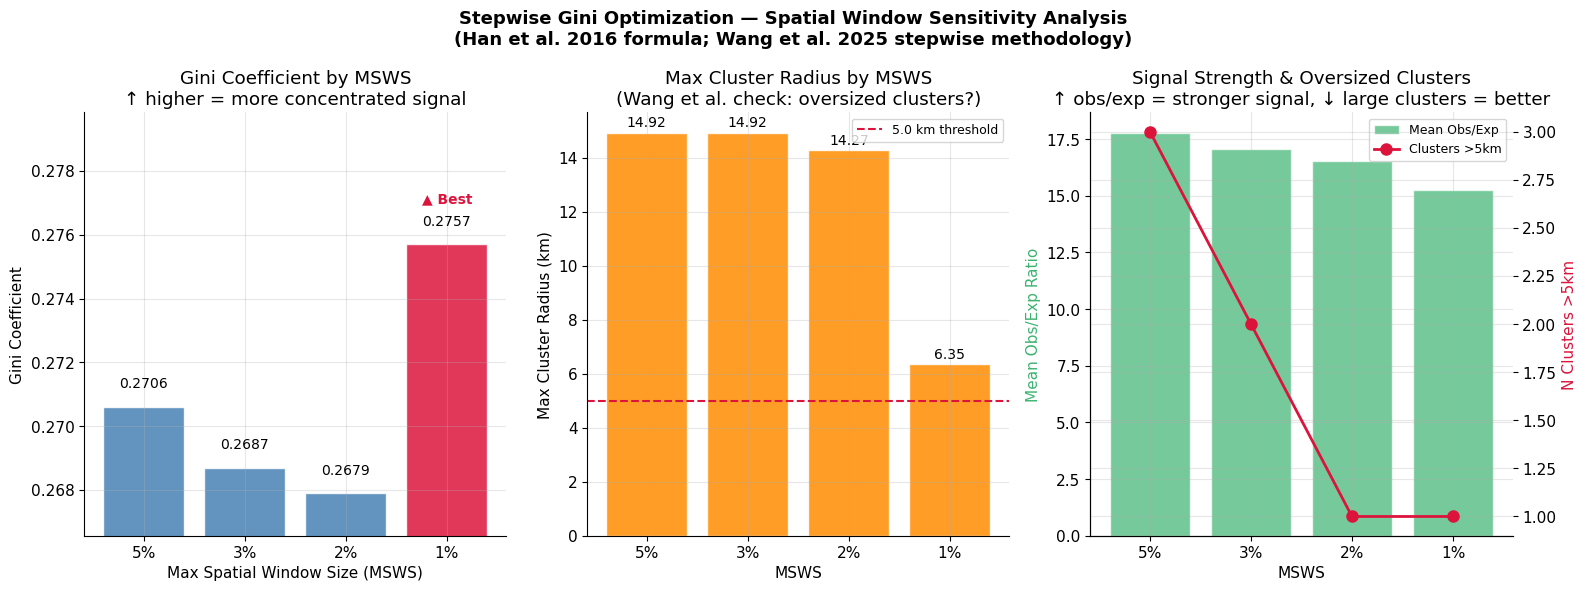

In [11]:
# ============================================================
# CELL 6 — Visualize Gini Comparison
#
# Two-panel visualization:
#   Left:  Gini coefficient by MSWS — the primary selection
#          criterion per Han et al. (2016) and Wang et al. (2025)
#   Right: Supporting metrics (max radius, mean obs/exp,
#          number of oversized clusters) to apply the Wang et al.
#          practical refinement alongside the Gini score
# ============================================================

labels   = list(results_df.index)
ginis    = results_df['Gini Coefficient'].values
max_r    = results_df['Max Radius (km)'].values
mean_oe  = results_df['Mean Obs/Exp'].values
n_large  = results_df[f'Clusters >{LARGE_CLUSTER_THRESHOLD_KM:.0f}km'].values

best_idx = np.argmax(ginis)
colors   = ['crimson' if i == best_idx else 'steelblue' for i in range(len(labels))]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    "Stepwise Gini Optimization — Spatial Window Sensitivity Analysis\n"
    "(Han et al. 2016 formula; Wang et al. 2025 stepwise methodology)",
    fontsize=13, fontweight='bold'
)

# Left: Gini scores
ax = axes[0]
bars = ax.bar(labels, ginis, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel("Max Spatial Window Size (MSWS)")
ax.set_ylabel("Gini Coefficient")
ax.set_title("Gini Coefficient by MSWS\n↑ higher = more concentrated signal")
for bar, val in zip(bars, ginis):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.annotate('▲ Best', xy=(best_idx, ginis[best_idx]),
            xytext=(0, 30), textcoords='offset points',
            ha='center', color='crimson', fontweight='bold', fontsize=10)
ax.set_ylim(min(ginis) * 0.995, max(ginis) * 1.015)

# Middle: Max radius
ax = axes[1]
ax.bar(labels, max_r, color='darkorange', alpha=0.85, edgecolor='white')
ax.axhline(LARGE_CLUSTER_THRESHOLD_KM, color='crimson', linestyle='--',
           linewidth=1.5, label=f'{LARGE_CLUSTER_THRESHOLD_KM} km threshold')
ax.set_xlabel("MSWS")
ax.set_ylabel("Max Cluster Radius (km)")
ax.set_title("Max Cluster Radius by MSWS\n(Wang et al. check: oversized clusters?)")
for i, val in enumerate(max_r):
    ax.text(i, val + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
ax.legend(fontsize=9)

# Right: Mean obs/exp + oversized cluster count
ax = axes[2]
ax2 = ax.twinx()
ax.bar(labels, mean_oe, color='mediumseagreen', alpha=0.7,
       edgecolor='white', label='Mean Obs/Exp')
ax2.plot(labels, n_large, color='crimson', marker='o',
         linewidth=2, markersize=8, label=f'Clusters >{LARGE_CLUSTER_THRESHOLD_KM:.0f}km')
ax.set_xlabel("MSWS")
ax.set_ylabel("Mean Obs/Exp Ratio", color='mediumseagreen')
ax2.set_ylabel(f"N Clusters >{LARGE_CLUSTER_THRESHOLD_KM:.0f}km", color='crimson')
ax.set_title("Signal Strength & Oversized Clusters\n↑ obs/exp = stronger signal, ↓ large clusters = better")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

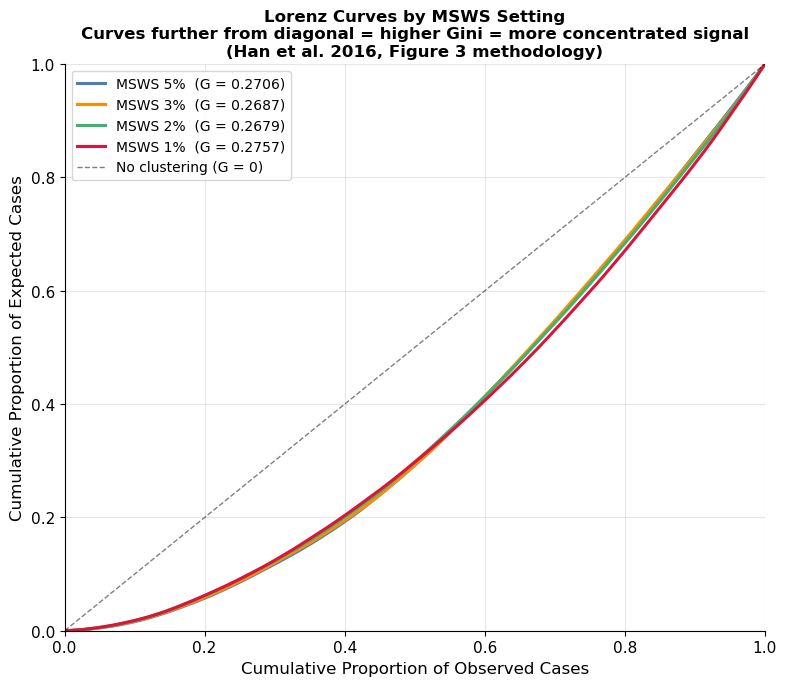


Interpretation:
  The curve that bows furthest below the diagonal has the highest
  Gini coefficient — meaning cases are most concentrated into
  high-rate clusters relative to what was expected by chance.
  That MSWS setting produces the most informative cluster structure.


In [12]:
# ============================================================
# CELL 7 — Lorenz Curves for Each Run
#
# Visualizes the Lorenz curve underlying each run's Gini score.
# The curve that bows furthest from the diagonal represents
# the most concentrated (unequal) distribution of cases —
# i.e. the highest Gini and best cluster structure.
#
# Per Han et al. (2016):
# "If there is a significant cluster in the study region,
# then the distribution of disease cases tends to be
# concentrated in the cluster, pushing the Lorenz curve
# further away from the reference line, and the value of
# the Gini coefficient will be higher."
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))
run_colors = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

for (label, df), color in zip(run_data.items(), run_colors):
    valid = df[['observed_cases', 'expected_cases']].dropna()
    valid = valid[(valid['observed_cases'] > 0) & (valid['expected_cases'] > 0)]
    obs = valid['observed_cases'].values.astype(float)
    exp = valid['expected_cases'].values.astype(float)
    rr  = obs / exp
    sort_idx = np.argsort(rr)[::-1]
    obs = obs[sort_idx]
    exp = exp[sort_idx]
    x = np.concatenate([[0], np.cumsum(obs) / obs.sum(), [1]])
    y = np.concatenate([[0], np.cumsum(exp) / exp.sum(), [1]])
    G = compute_gini(df)
    ax.plot(x, y, color=color, linewidth=2.2,
            label=f'MSWS {label}  (G = {G:.4f})')

# Reference line (perfect equality = no clustering)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='No clustering (G = 0)')

ax.set_xlabel("Cumulative Proportion of Observed Cases", fontsize=12)
ax.set_ylabel("Cumulative Proportion of Expected Cases", fontsize=12)
ax.set_title(
    "Lorenz Curves by MSWS Setting\n"
    "Curves further from diagonal = higher Gini = more concentrated signal\n"
    "(Han et al. 2016, Figure 3 methodology)",
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  The curve that bows furthest below the diagonal has the highest")
print("  Gini coefficient — meaning cases are most concentrated into")
print("  high-rate clusters relative to what was expected by chance.")
print("  That MSWS setting produces the most informative cluster structure.")

In [15]:
# ============================================================
# CELL 8 — Final Recommendation Summary
#
# Synthesizes findings from Han et al. (2016) Gini formula
# and Wang et al. (2025) practical refinement to produce
# a documented, citable parameter selection decision.
#
# NOTE: The final MSWS choice requires domain judgment.
# Wang et al. (2025) do not prescribe a fixed rule for
# handling cases where the highest-Gini setting still
# produces large clusters. They combined Gini scores with
# qualitative assessment of cluster sizes specific to their
# data. The summary below presents the information needed
# to make that judgment for your dataset.
# ============================================================

print("=" * 65)
print("  GINI OPTIMIZATION SUMMARY")
print("  Methodology: Wang et al. (2025) stepwise comparison")
print("  Formula:     Han et al. (2016) Gini coefficient")
print("=" * 65)

ranked = results_df['Gini Coefficient'].sort_values(ascending=False)
print(f"\n  Gini ranking (highest to lowest):\n")
print(f"  {'Rank':<6} {'MSWS':<8} {'Gini':>8}  {'Max Radius (km)':>16}  {'Mean Obs/Exp':>13}  {'% <0.5km':>9}")
print(f"  {'-'*65}")
for i, (msws, G) in enumerate(ranked.items()):
    max_r   = results_df.loc[msws, 'Max Radius (km)']
    mean_oe = results_df.loc[msws, 'Mean Obs/Exp']
    pct_sm  = results_df.loc[msws, '% Under 0.5km']
    best_marker = "  ← highest Gini" if i == 0 else ""
    print(f"  {i+1:<6} {msws:<8} {G:>8.4f}  {max_r:>16.3f}  {mean_oe:>13.2f}x  {pct_sm:>9.1f}%{best_marker}")

print(f"""
  Interpretation guidance:
  ─────────────────────────────────────────────────────────────
  The MSWS with the highest Gini coefficient produces the most
  concentrated, best-differentiated cluster structure across
  the dataset (Han et al. 2016).

  Wang et al. (2025) found in practice that "simply using the
  Gini coefficient as a criterion for determining MSWS is
  insufficient" and recommend assessing cluster sizes alongside
  the Gini score. Their judgment of what constitutes "too large"
  was qualitative and specific to their Wuhan TB dataset —
  no universal km threshold is defined in the paper.

  For your dataset, consider:
    1. Does the highest-Gini MSWS produce clusters that are
       geographically meaningful at your study scale?
    2. If not, which lower-Gini MSWS produces the best
       combination of signal concentration AND cluster size?
    3. Does the persistent large cluster across all % windows
       suggest a fixed km distance cap is more appropriate
       than a percentage-based MSWS?

  References:
  Han et al. (2016) Int J Health Geogr 15:27
  https://doi.org/10.1186/s12942-016-0056-6
  Wang et al. (2025) Front Public Health 12:1432645
  https://doi.org/10.3389/fpubh.2024.1432645
  {"=" * 63}""")

  GINI OPTIMIZATION SUMMARY
  Methodology: Wang et al. (2025) stepwise comparison
  Formula:     Han et al. (2016) Gini coefficient

  Gini ranking (highest to lowest):

  Rank   MSWS         Gini   Max Radius (km)   Mean Obs/Exp   % <0.5km
  -----------------------------------------------------------------
  1      1%         0.2757             6.350          15.25x       91.0%  ← highest Gini
  2      5%         0.2706            14.924          17.79x       90.8%
  3      3%         0.2687            14.924          17.05x       90.8%
  4      2%         0.2679            14.267          16.52x       91.2%

  Interpretation guidance:
  ─────────────────────────────────────────────────────────────
  The MSWS with the highest Gini coefficient produces the most
  concentrated, best-differentiated cluster structure across
  the dataset (Han et al. 2016).

  Wang et al. (2025) found in practice that "simply using the
  Gini coefficient as a criterion for determining MSWS is
  insufficien